# Preprocessing of Data sources

This notebook shows how to gather the data from various data sources required for the IWU estimates and also performs pre-processing steps like regridding the various datasets to the same spatial and temporal dimensions and convert the units of the variables to the requested ones.

**Output**: A unified pre-processed dataset ready for calibration and predictions 

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import geopandas as gpd
import json
import matplotlib.pyplot as plt

from xcube.core.store import new_data_store
from xcube.core.chunk import chunk_dataset
from xcube.core.gridmapping import GridMapping
from xcube.core.geom import mask_dataset_by_geometry
from xcube_resampling.spatial import resample_in_space
from xcube_resampling.gridmapping import GridMapping

First lets load the shapefile providing us with the region that we will create our dataset for development and testing purposes.

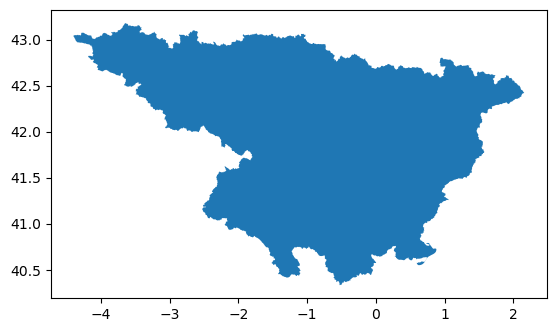

In [2]:
gdf = gpd.read_file("ebro_data/Limite_Cuenca_Ebro84.shp")
gdf.plot()
plt.show()

In [3]:
print(gdf.crs) 

EPSG:4326


In [4]:
# To be used for all the data sources

# bbox = [-31, 27, 40, 81] # Europe
bbox = [-5, 40, 3, 44] # Ebro Basin
time_range = ("2020-01-01", "2020-01-31")

In [5]:
### Land Cover

cci_ds = new_data_store("cciodp")
lc_cci = cci_ds.open_data(
    "esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform.Map.2-0-7.r1", 
    bbox=bbox, 
    time_range=["2015-01-01", "2015-12-31"], # LandCover has different time-range because this is the latest data available via CCI.
)
lc_cci

<xarray.Dataset> Size: 83MB
Dimensions:              (time: 1, lat: 1440, lon: 2880, bnds: 2)
Coordinates:
  * lat                  (lat) float32 6kB 44.0 44.0 43.99 ... 40.01 40.0 40.0
  * lon                  (lon) float32 12kB -4.999 -4.996 -4.993 ... 2.996 2.999
  * time                 (time) datetime64[ns] 8B 2015-07-02T12:00:00
    time_bnds            (time, bnds) datetime64[ns] 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    change_count         (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    crs                  float64 8B ...
    current_pixel_state  (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    lccs_class           (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    observation_count    (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
    processed_flag       (time, lat, lon) float32 17MB dask.array<chunksize=(1, 1440, 2880), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    title:                   esacci.LC.yr.L4.LCCS.multi-sensor.multi-platform...
    date_created:            2025-08-27T13:18:45.813343
    processing_level:        L4
    time_coverage_start:     2015-01-01T00:00:00
    time_coverage_end:       2016-01-01T00:00:00
    time_coverage_duration:  P365DT0H0M0S
    history:                 [{'program': 'xcube_cci.chunkstore.CciChunkStore...

CPU times: user 102 ms, sys: 32.8 ms, total: 135 ms
Wall time: 9.82 s


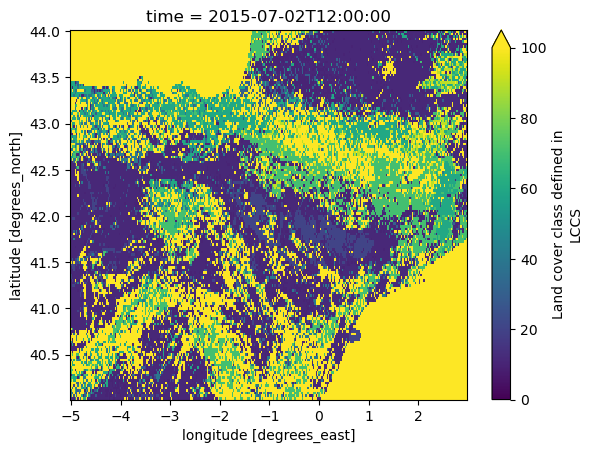

In [6]:
%%time
downsampled_cube = lc_cci.lccs_class.isel(
    lat=slice(None, None, 10),
    lon=slice(None, None, 10),
)
downsampled_cube.plot(vmin=0, vmax=100)

In [7]:
# ERA5

cds_store = new_data_store("cds", normalize_names=True)

data_id = 'reanalysis-era5-land'
variables = ("soil_temperature_level_1", "potential_evaporation", "total_precipitation", "snowfall")
spatial_res = 0.1

cds_cube = cds_store.open_data(
    data_id,
    cds_store.get_data_opener_ids()[0],
    variable_names=variables,
    bbox=bbox,
    spatial_res=spatial_res,
    time_range=time_range
)

xcube-cds version 1.1.0.dev0
2025-08-27 13:18:56,037 INFO [2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
INFO:ecmwf.datastores.legacy_client:[2024-09-26T00:00:00] Watch our [Forum](https://forum.ecmwf.int/) for Announcements, news and other discussed topics.
2025-08-27 13:18:56,376 INFO Request ID is b1c9f730-4eef-417d-bc05-45c5c28c91d1
INFO:ecmwf.datastores.legacy_client:Request ID is b1c9f730-4eef-417d-bc05-45c5c28c91d1
2025-08-27 13:18:56,462 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2025-08-27 13:19:05,030 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2025-08-27 13:27:15,744 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


973af8aece1f0eff25f7c9574da6ff24.zip:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

In [8]:
cds_cube

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 744, lat: 40, lon: 80)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
    expver   (time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    stl1     (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-27T11:25 GRIB to CDM+CF via cfgrib-0.9.1...

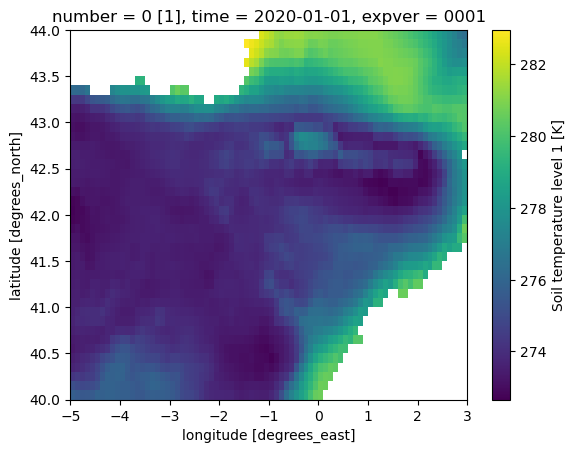

In [9]:
cds_cube.isel(time=0).stl1.plot()

In [10]:
# time_range = ('2020-01-01', '2020-01-20')

In [11]:
%%time
# CLMS

json_file_path = "credentials.json"
with open(json_file_path, "r") as j:
    credentials = json.loads(j.read())

clms_data_store = new_data_store("clms", credentials=credentials)

clms_data = clms_data_store.open_data("daily-surface-soil-moisture-v1.0", time_range=time_range)
clms_data

INFO:xcube.clms:Fetching datasets metadata from https://land.copernicus.eu/api
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=25&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=50&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=75&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=100&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=125&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search/?b_start=150&portal_type=DataSet&fullobjects=1
DEBUG:xcube.clms:Making a request to https://land.copernicus.eu/api/@search

CPU times: user 2.11 s, sys: 416 ms, total: 2.53 s
Wall time: 39.5 s


<xarray.Dataset> Size: 7GB
Dimensions:    (time: 31, lat: 4144, lon: 6832)
Coordinates:
  * lat        (lat) float64 33kB 72.0 71.99 71.98 71.97 ... 35.02 35.01 35.0
  * lon        (lon) float64 55kB -11.0 -10.99 -10.98 ... 49.98 49.99 50.0
  * time       (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    crs        (time) |S1 31B b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    ssm        (time, lat, lon) float32 4GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
    ssm_noise  (time, lat, lon) float32 4GB dask.array<chunksize=(1, 1382, 2278), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [12]:
%%time
clms_data = clms_data.sel(lat=slice(44, 40), lon=slice(-5, 3))

CPU times: user 2.46 ms, sys: 1.82 ms, total: 4.28 ms
Wall time: 3.4 ms


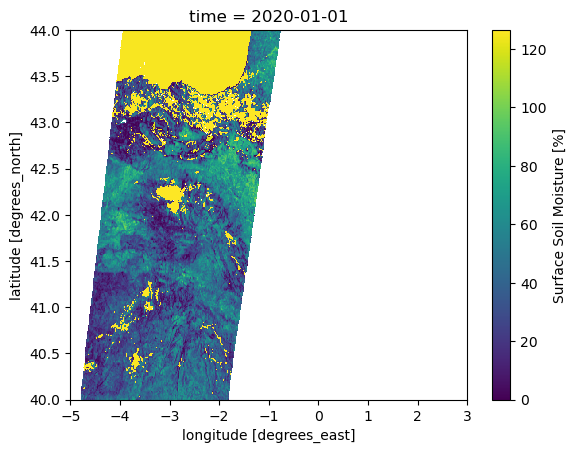

In [13]:
# clms_data.isel(time=0, lat=slice(None, None, 50), lon=slice(None, None, 50)).ssm.plot()
clms_data.isel(time=0).ssm.plot()

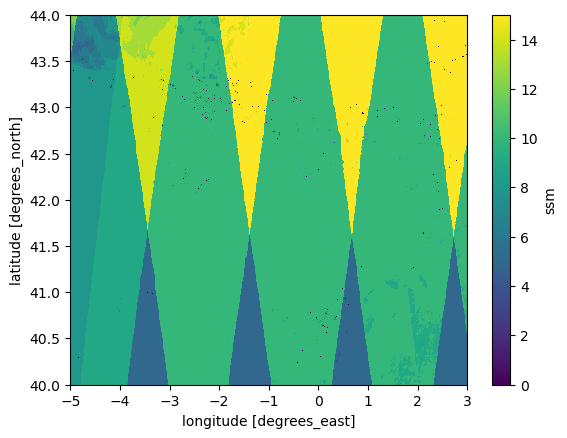

In [14]:
clms_data.ssm.count(dim='time').plot()

## Preprocessing

### Soil Moisture (CLMS) - Interpolation

In [159]:
def swicomp_nan(in_data, in_jd, ctime=2):
    filtered = np.empty(len(in_data))
    gain = 1
    filtered.fill(np.nan)

    ID = np.where(~np.isnan(in_data))
    if len(ID[0]) == 0:
        return filtered

    D = in_jd[ID]
    SWI = in_data[ID].copy()
    tdiff = np.diff(D)

    for i in range(2, SWI.size):
        gain = gain / (gain + np.exp(- tdiff[i - 1] / ctime))
        SWI[i] = SWI[i - 1] + gain * (SWI[i] - SWI[i-1])

    filtered[ID] = SWI
    return filtered

In [160]:
julian_dates = xr.DataArray(
    pd.to_datetime(clms_data.time.values).to_julian_date().values,
    dims='time',
    coords={'time': clms_data.time}
)
julian_dates

<xarray.DataArray (time: 31)> Size: 248B
array([2458849.5, 2458850.5, 2458851.5, 2458852.5, 2458853.5, 2458854.5,
       2458855.5, 2458856.5, 2458857.5, 2458858.5, 2458859.5, 2458860.5,
       2458861.5, 2458862.5, 2458863.5, 2458864.5, 2458865.5, 2458866.5,
       2458867.5, 2458868.5, 2458869.5, 2458870.5, 2458871.5, 2458872.5,
       2458873.5, 2458874.5, 2458875.5, 2458876.5, 2458877.5, 2458878.5,
       2458879.5])
Coordinates:
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31

In [161]:
clms_data

<xarray.Dataset> Size: 249MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    crs            (time) |S1 31B b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    ssm            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [162]:
clms_data_chunked = clms_data.chunk({'time': -1})
clms_data_chunked

<xarray.Dataset> Size: 249MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    crs            (time) |S1 31B dask.array<chunksize=(31,), meta=np.ndarray>
    ssm            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [163]:
sm_filled = clms_data_chunked['ssm'].interpolate_na(dim='time', method='linear') #, fill_value="extrapolate") ?
sm_filled

<xarray.DataArray 'ssm' (time: 31, lat: 448, lon: 896)> Size: 50MB
dask.array<transpose, shape=(31, 448, 896), dtype=float32, chunksize=(31, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Attributes:
    Class:          DATA
    grid_mapping:   crs
    flag_values:    [241 242 251 252 253]
    flag_meanings:  ExceedingMin ExceedingMax WaterMask SensitivityMask Slope...
    long_name:      Surface Soil Moisture
    units:          %
    valid_range:    [  0 200]

In [164]:
sm_clipped = sm_filled.clip(max=100)

sm_normalized = (sm_clipped - sm_clipped.min()) / (sm_clipped.max() - sm_clipped.min())
sm_normalized

<xarray.DataArray 'ssm' (time: 31, lat: 448, lon: 896)> Size: 50MB
dask.array<truediv, shape=(31, 448, 896), dtype=float32, chunksize=(31, 448, 896), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31

In [165]:
sm_normalized.min().values, sm_normalized.max().values

(array(0., dtype=float32), array(1., dtype=float32))

In [166]:
SWI = xr.apply_ufunc(
    swicomp_nan,
    sm_normalized,       
    julian_dates,
    input_core_dims=[["time"], ["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized", 
    kwargs={"ctime": 2},
    output_dtypes=[clms_data.ssm.dtype]
)

In [167]:
SWI

<xarray.DataArray (lat: 448, lon: 896, time: 31)> Size: 50MB
dask.array<transpose, shape=(448, 896, 31), dtype=float32, chunksize=(448, 896, 31), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.03 40.02 40.01 40.0
  * lon      (lon) float64 7kB -4.996 -4.987 -4.978 -4.969 ... 2.978 2.987 2.996
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31

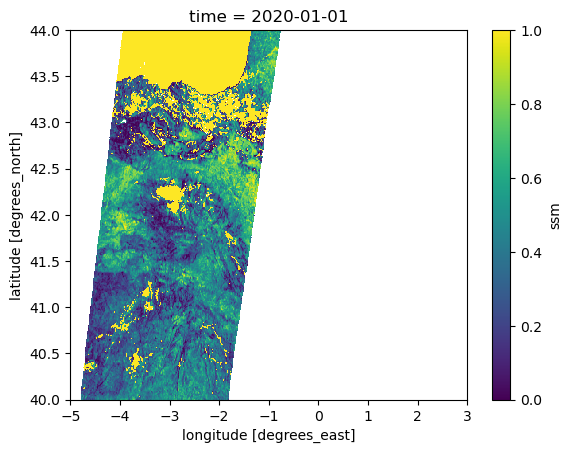

In [168]:
sm_normalized.isel(time=0).plot()

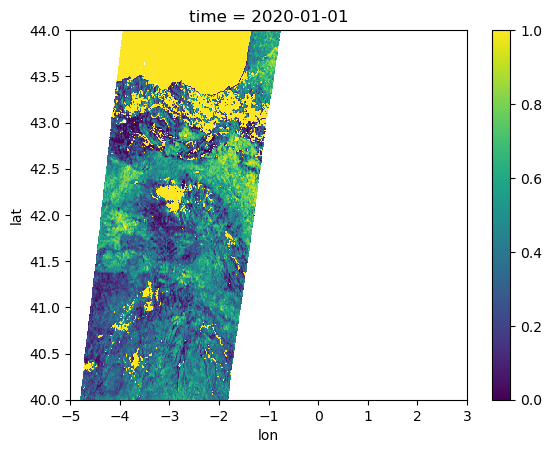

In [169]:
SWI.isel(time=0).plot()

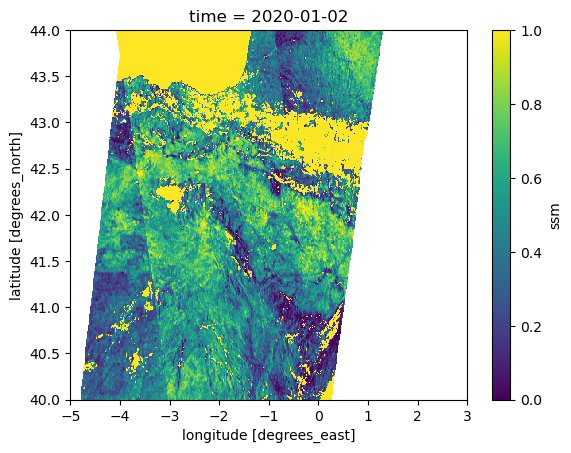

In [170]:
sm_normalized.isel(time=1).plot()

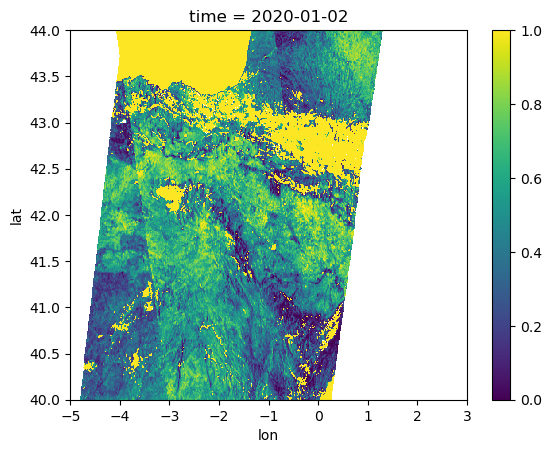

In [171]:
SWI.isel(time=1).plot()

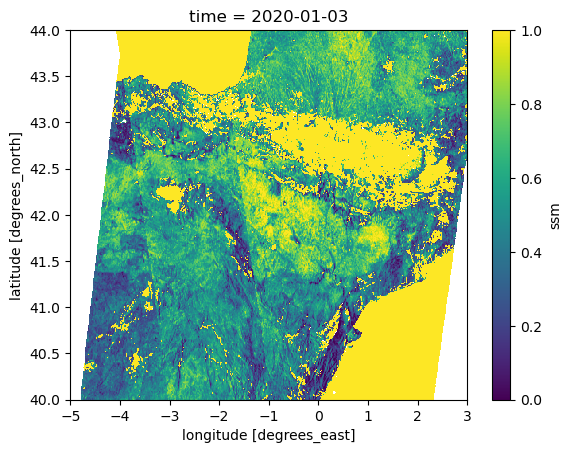

In [172]:
sm_normalized.isel(time=2).plot()

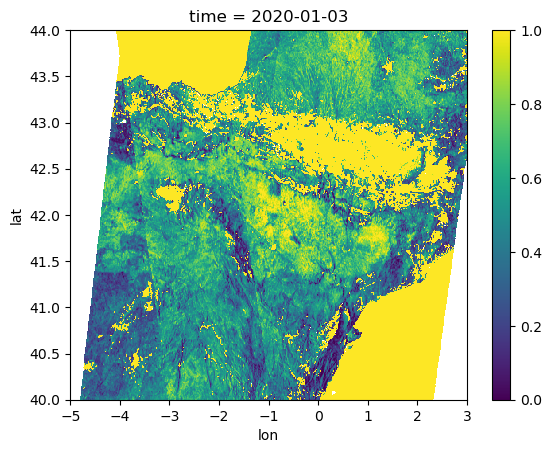

In [173]:
SWI.isel(time=2).plot()

In [174]:
clms_data["SWI"] = SWI.transpose("time", "lat", "lon")
clms_data["sm_normalized"] = sm_normalized
clms_data["sm_filled"] = sm_filled

In [175]:
fsd = new_data_store("file", root="output_ebro")

In [177]:
%%time
fsd.write_data(clms_data, "soil_moisture_filled.zarr")

CPU times: user 24.3 s, sys: 729 ms, total: 25.1 s
Wall time: 22.9 s


'soil_moisture_filled.zarr'

In [178]:
soil_moisture = fsd.open_data("soil_moisture_filled.zarr")

In [179]:
soil_moisture

<xarray.Dataset> Size: 348MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(31,), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [180]:
soil_moisture["sm_filled"].attrs["long_name"] = "Gap-filled soil moisture"

In [181]:
### Mask CDS with LandCover and convert the LC to 0-1 bool

In [182]:
keep_classes = [10, 11, 12, 20, 30] # These are classes in LandCover related to Croplands

filtered_lc = lc_cci.lccs_class.where(lc_cci["lccs_class"].isin(keep_classes))
filtered_lc

<xarray.DataArray 'lccs_class' (time: 1, lat: 1440, lon: 2880)> Size: 17MB
dask.array<where, shape=(1, 1440, 2880), dtype=float32, chunksize=(1, 1440, 2880), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 6kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float32 12kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
  * time     (time) datetime64[ns] 8B 2015-07-02T12:00:00
Attributes: (12/16)
    long_name:            Land cover class defined in LCCS
    standard_name:        land_cover_lccs
    flag_values:          [0, 10, 11, 12, 20, 30, 40, 50, 60, 61, 62, 70, 71,...
    flag_meanings:        no_data cropland_rainfed cropland_rainfed_herbaceou...
    valid_min:            1
    valid_max:            220
    ...                   ...
    shape:                [1, 1440, 2880]
    chunk_sizes:          [1, 1440, 2880]
    file_chunk_sizes:     [1440, 2880]
    data_type:            uint8
    dimensions:           ['time', 'lat', 'lon']
    file_dimensions:      ['lat', 'lon']

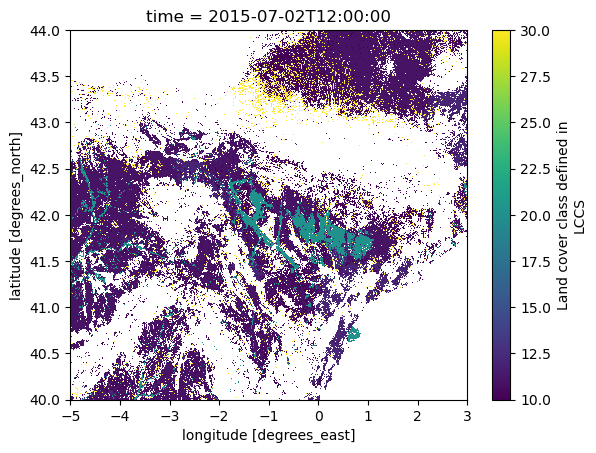

In [183]:
filtered_lc.plot()

In [184]:
total = filtered_lc.size                    
non_nan = int(filtered_lc.count().compute())
nan_count = total - non_nan

In [185]:
total, non_nan, nan_count

(4147200, 1605286, 2541914)

In [186]:
keep_classes_np = np.array(keep_classes, dtype=filtered_lc.dtype)
lc_binary = filtered_lc.isin(keep_classes_np).astype("uint8")
lc_binary

<xarray.DataArray 'lccs_class' (time: 1, lat: 1440, lon: 2880)> Size: 4MB
dask.array<astype, shape=(1, 1440, 2880), dtype=uint8, chunksize=(1, 1440, 2880), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float32 6kB 44.0 44.0 43.99 43.99 ... 40.01 40.01 40.0 40.0
  * lon      (lon) float32 12kB -4.999 -4.996 -4.993 -4.99 ... 2.993 2.996 2.999
  * time     (time) datetime64[ns] 8B 2015-07-02T12:00:00

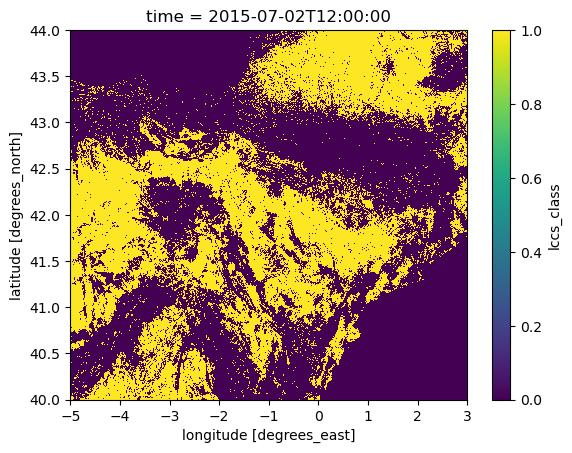

In [187]:
lc_binary.plot()

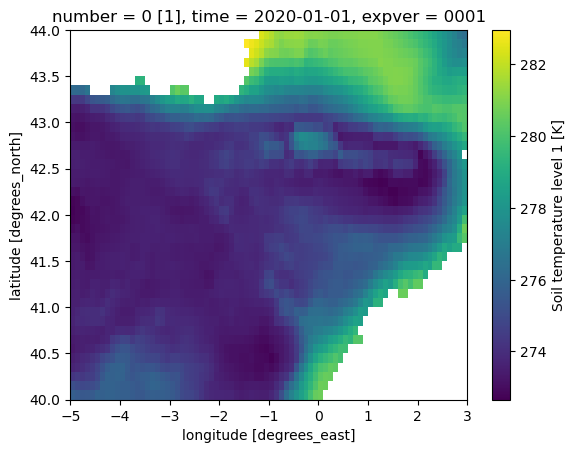

In [188]:
cds_cube.stl1.isel(time=0).plot()

In [189]:
soil_moisture

<xarray.Dataset> Size: 348MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    crs            (time) |S1 31B dask.array<chunksize=(31,), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 448, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/26)
    Conventions:               CF-1.6
    archive_facility:          VITO
    copyright:                 Copernicus Service information 2020
    geospatial_lat_max:        72.0
    geospatial_lat_min:        35.0
    geospatial_lon_max:        50.0
    ...                        ...
    region_name:               CEURO
    sensor:                    CSAR
    source:                    Derived from EO radar observations
    time_coverage_end:         2020-01-01T23:59:59Z
    time_coverage_start:       2020-01-01T00:00:00Z
    title:                     Daily Surface Soil Moisture 1km: CEURO 2020-01...

In [190]:
cds_cube

<xarray.Dataset> Size: 38MB
Dimensions:  (time: 744, lat: 40, lon: 80)
Coordinates:
    number   int64 8B ...
  * time     (time) datetime64[ns] 6kB 2020-01-01 ... 2020-01-31T23:00:00
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
    expver   (time) <U4 12kB dask.array<chunksize=(744,), meta=np.ndarray>
Data variables:
    stl1     (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 10MB dask.array<chunksize=(744, 40, 80), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-08-27T11:25 GRIB to CDM+CF via cfgrib-0.9.1...

In [191]:
stl1_daily = cds_cube["stl1"].resample(time="1D").mean()
pev_daily  = cds_cube["pev"].resample(time="1D").sum() * -1    
tp_daily   = cds_cube["tp"].resample(time="1D").max()
sf_daily   = cds_cube["sf"].resample(time="1D").mean()

cds_cube_daily = xr.merge([stl1_daily, pev_daily, tp_daily, sf_daily])

In [192]:
cds_cube_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 40, lon: 80, time: 31)
Coordinates:
    number   int64 8B 0
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1     (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [193]:
gm_sm = GridMapping.from_dataset(soil_moisture)
gm_sm

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [194]:
gm_cds = GridMapping.from_dataset(cds_cube_daily)
gm_cds

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.1, 0.1)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 80, 40)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (80, 40)
* tile_size: (80, 40)

In [195]:
gm_lc = GridMapping.from_dataset(lc_binary.to_dataset(name="lc_binary"))
gm_lc

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: EPSG:4326
* xy_res: (0.002777575, 0.0027771)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 2880, 1440)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (2880, 1440)
* tile_size: (2880, 1440)

In [196]:
cds_cube_daily

<xarray.Dataset> Size: 2MB
Dimensions:  (lat: 40, lon: 80, time: 31)
Coordinates:
    number   int64 8B 0
  * lat      (lat) float64 320B 43.95 43.85 43.75 43.65 ... 40.25 40.15 40.05
  * lon      (lon) float64 640B -4.95 -4.85 -4.75 -4.65 ... 2.65 2.75 2.85 2.95
  * time     (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1     (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    pev      (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    tp       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
    sf       (time, lat, lon) float32 397kB dask.array<chunksize=(1, 40, 80), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [197]:
cds_in_gm_sm = resample_in_space(cds_cube_daily, target_gm = gm_sm)
cds_in_gm_sm = cds_in_gm_sm.assign_coords(time=cds_cube_daily.time) # this step is needed until resample_in_space is fixed
cds_in_gm_sm

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [198]:
lc_binary.attrs['flag_values'] = [0, 1]
lc_binary.attrs['flag_meanings'] = "no_data croplands_land_cover"

In [199]:
lc_in_gm_sm = resample_in_space(lc_binary.to_dataset(name="lc_binary").isel(time=0), target_gm = gm_sm, agg_methods="mode")
lc_in_gm_sm=lc_in_gm_sm.drop_vars('time')
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

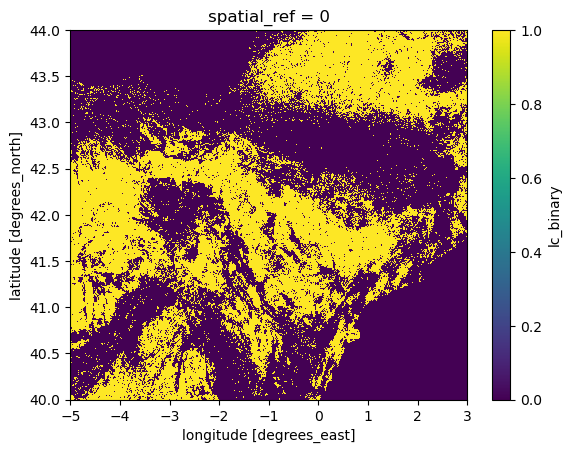

In [200]:
lc_in_gm_sm.lc_binary.plot()

In [201]:
GridMapping.from_dataset(lc_in_gm_sm)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [202]:
GridMapping.from_dataset(cds_in_gm_sm)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: False
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (896, 448)

In [203]:
cds_in_gm_sm

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [204]:
lc_in_gm_sm

<xarray.Dataset> Size: 412kB
Dimensions:      (lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    spatial_ref  int64 8B 0
Data variables:
    lc_binary    (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>

In [205]:
cds_masked_full = cds_in_gm_sm.where(lc_in_gm_sm.lc_binary == 1)
cds_masked_full

<xarray.Dataset> Size: 199MB
Dimensions:      (time: 31, lat: 448, lon: 896)
Coordinates:
  * lon          (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * lat          (lat) float64 4kB 44.0 43.99 43.98 43.97 ... 40.02 40.01 40.0
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    pev          (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    tp           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
    sf           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 448, 896), meta=np.ndarray>
Attributes: (12/32)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                Soil temperature level 1
    units:                                    K
    standard_name:                            surface_temperature
    GRIB_depthBelowLandLayer:                 0.0

In [206]:
cds_masked = mask_dataset_by_geometry(cds_masked_full, gdf.geometry[0])

In [207]:
soil_moisture = soil_moisture.where(lc_in_gm_sm.lc_binary == 1)

In [208]:
soil_moisture = mask_dataset_by_geometry(soil_moisture, gdf.geometry[0])

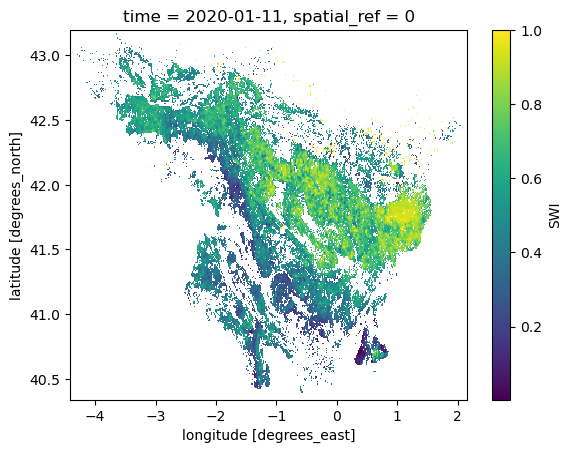

In [209]:
soil_moisture.SWI.isel(time=10).plot()

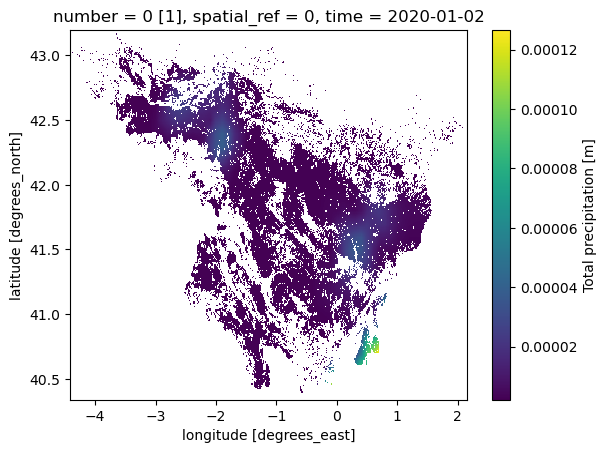

In [210]:
cds_masked.tp.isel(time=1).plot()

In [211]:
def convert_m_to_mm(dataarray, update_long_name=True):
    """
    Convert DataArray values from meters to millimeters.

    Parameters:
    - dataarray: xarray.DataArray, the input data with units in meters.
    - update_long_name: bool, if True, appends '(millimeters)' to long_name attribute.

    Returns:
    - xarray.DataArray with values multiplied by 1000 and updated attributes.
    """
    converted = dataarray * 1000

    converted.attrs = dataarray.attrs.copy()

    converted.attrs['units'] = 'mm'
    converted.attrs['GRIB_units'] = 'mm'
 
    if update_long_name:
        if 'long_name' in converted.attrs:
            converted.attrs['long_name'] = converted.attrs['long_name'] + ' (millimeters)'
        else:
            converted.attrs['long_name'] = 'Potential evaporation (millimeters)'

    return converted


In [212]:
cds_masked["pev"] =  convert_m_to_mm(cds_masked["pev"])
cds_masked["tp"] =  convert_m_to_mm(cds_masked["tp"])
cds_masked

<xarray.Dataset> Size: 117MB
Dimensions:      (lon: 736, lat: 320, time: 31)
Coordinates:
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    pev          (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    tp           (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sf           (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/43)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    geospatial_lat_min:                       40.339285712498786
    geospatial_lat_max:                       43.19642857321242
    geospatial_lat_resolution:                0.008928575
    geospatial_bounds_crs:                    CRS84
    geospatial_bounds:                        POLYGON((-4.410714287500187 40....
    date_modified:                            2025-08-27T16:09:20.242566

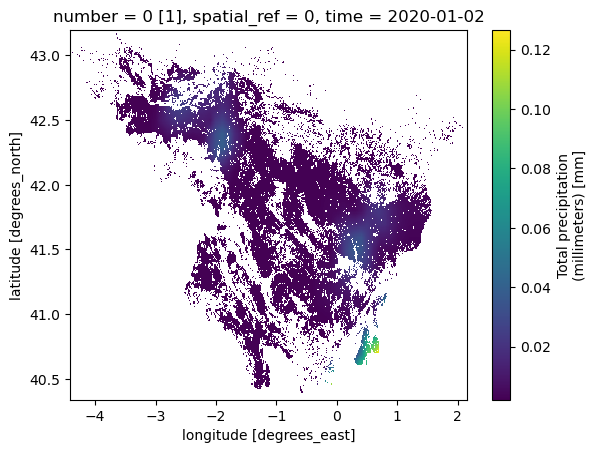

In [213]:
cds_masked.tp.isel(time=1).plot()

In [214]:
soil_moisture

<xarray.Dataset> Size: 263MB
Dimensions:        (lat: 320, lon: 736, time: 31)
Coordinates:
  * lat            (lat) float64 3kB 43.19 43.18 43.17 ... 40.36 40.35 40.34
  * lon            (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
    spatial_ref    int64 8B 0
Data variables:
    SWI            (time, lat, lon) float32 29MB dask.array<chunksize=(31, 320, 736), meta=np.ndarray>
    crs            (time, lat, lon) object 58MB dask.array<chunksize=(31, 320, 736), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 29MB dask.array<chunksize=(31, 320, 736), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 29MB dask.array<chunksize=(31, 320, 736), meta=np.ndarray>
    ssm            (time, lat, lon) float64 58MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 58MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-27T16:09:20.431544

In [215]:
cds_masked

<xarray.Dataset> Size: 117MB
Dimensions:      (lon: 736, lat: 320, time: 31)
Coordinates:
  * lon          (lon) float64 6kB -4.406 -4.397 -4.388 ... 2.138 2.147 2.156
  * lat          (lat) float64 3kB 43.19 43.18 43.17 43.17 ... 40.36 40.35 40.34
    number       int64 8B 0
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 248B 2020-01-01 2020-01-02 ... 2020-01-31
Data variables:
    stl1         (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    pev          (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    tp           (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
    sf           (time, lat, lon) float32 29MB dask.array<chunksize=(1, 320, 736), meta=np.ndarray>
Attributes: (12/43)
    GRIB_paramId:                             139
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      3200
    GRIB_typeOfLevel:                         depthBelowLandLayer
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    geospatial_lat_min:                       40.339285712498786
    geospatial_lat_max:                       43.19642857321242
    geospatial_lat_resolution:                0.008928575
    geospatial_bounds_crs:                    CRS84
    geospatial_bounds:                        POLYGON((-4.410714287500187 40....
    date_modified:                            2025-08-27T16:09:20.242566

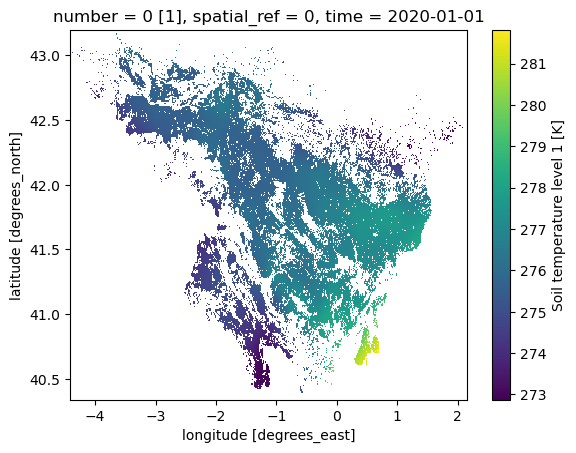

In [216]:
cds_masked.stl1.isel(time=0).plot()

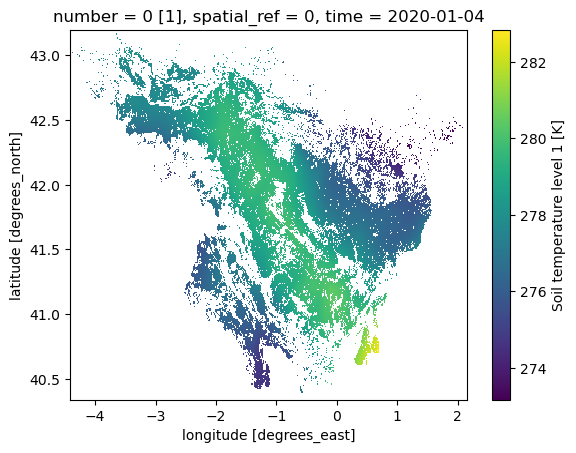

In [217]:
cds_masked.stl1.isel(time=3).plot()

In [218]:
ds_combined = xr.merge([soil_moisture, cds_masked, lc_in_gm_sm])
ds_combined

<xarray.Dataset> Size: 647MB
Dimensions:        (lat: 448, lon: 896, time: 31)
Coordinates:
  * lat            (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
    spatial_ref    int64 8B 0
    number         int64 8B 0
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    crs            (time, lat, lon) object 100MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 320, 896), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(1, 320, 896), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(448, 896), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-27T16:09:20.431544

In [219]:
chunked_ds = chunk_dataset(ds_combined, chunk_sizes={"time":-1, "lat":128, "lon":128}, format_name="zarr")

In [220]:
chunked_ds

<xarray.Dataset> Size: 647MB
Dimensions:        (lat: 448, lon: 896, time: 31)
Coordinates:
  * lat            (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
    spatial_ref    int64 8B 0
    number         int64 8B 0
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    crs            (time, lat, lon) object 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    geospatial_lat_max:         43.19642857321242
    geospatial_lat_min:         40.339285712498786
    geospatial_lon_max:         2.160714287499627
    ...                         ...
    geospatial_lon_resolution:  0.008928575
    geospatial_lat_units:       degrees_north
    geospatial_lat_resolution:  0.008928575
    geospatial_bounds_crs:      CRS84
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    date_modified:              2025-08-27T16:09:20.431544

In [221]:
fsd.write_data(chunked_ds, "irrigation_input.zarr")

/home/yogesh/Projects/BC/irrigation-processor/.pixi/envs/default/lib/python3.12/site-packages/xcube/core/store/fs/impl/dataset.py:207: SerializationWarning: variable None has data in the form of a dask array with dtype=object, which means it is being loaded into memory to determine a data type that can be safely stored on disk. To avoid this, coerce this variable to a fixed-size dtype with astype() before saving it.
  data.to_zarr(


'irrigation_input.zarr'

In [222]:
irrigation_input=fsd.open_data("irrigation_input.zarr")
irrigation_input

<xarray.Dataset> Size: 647MB
Dimensions:        (time: 31, lat: 448, lon: 896)
Coordinates:
  * lat            (lat) float64 4kB 40.0 40.01 40.02 40.03 ... 43.98 43.99 44.0
  * lon            (lon) float64 7kB -4.996 -4.987 -4.978 ... 2.978 2.987 2.996
    number         int64 8B ...
    spatial_ref    int64 8B ...
  * time           (time) datetime64[ns] 248B 2020-01-01 ... 2020-01-31
Data variables:
    SWI            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    crs            (time, lat, lon) |S8 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    lc_binary      (lat, lon) uint8 401kB dask.array<chunksize=(128, 128), meta=np.ndarray>
    pev            (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sf             (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_filled      (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    sm_normalized  (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm            (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    ssm_noise      (time, lat, lon) float64 100MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    stl1           (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
    tp             (time, lat, lon) float32 50MB dask.array<chunksize=(31, 128, 128), meta=np.ndarray>
Attributes: (12/33)
    Conventions:                CF-1.6
    archive_facility:           VITO
    copyright:                  Copernicus Service information 2020
    date_modified:              2025-08-27T16:09:20.431544
    geospatial_bounds:          POLYGON((-4.410714287500187 40.33928571249878...
    geospatial_bounds_crs:      CRS84
    ...                         ...
    region_name:                CEURO
    sensor:                     CSAR
    source:                     Derived from EO radar observations
    time_coverage_end:          2020-01-01T23:59:59Z
    time_coverage_start:        2020-01-01T00:00:00Z
    title:                      Daily Surface Soil Moisture 1km: CEURO 2020-0...

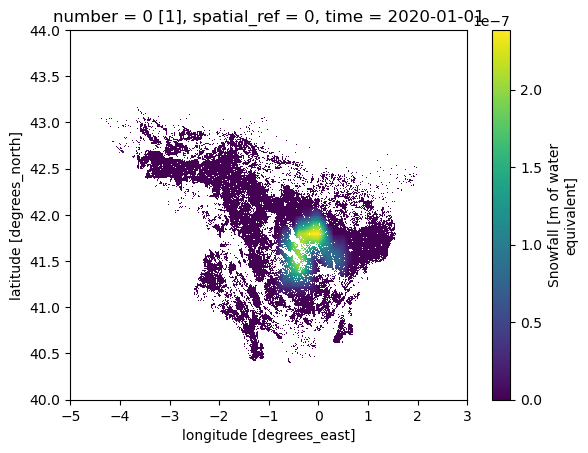

In [223]:
irrigation_input.sf.isel(time=0).plot()

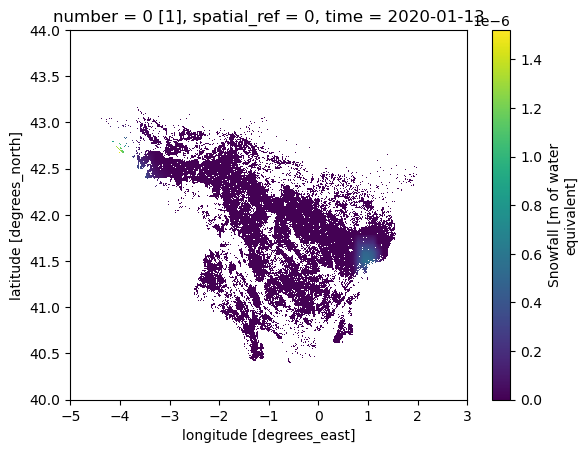

In [224]:
irrigation_input.sf.isel(time=12).plot()

In [225]:
from xcube.webapi.viewer import Viewer
viewer = Viewer()

INFO:xcube:Loaded service API 'auth'
INFO:xcube:Loaded service API 'styles'
INFO:xcube:Loaded service API 'viewer'
INFO:xcube:Loaded service API 'meta'
INFO:xcube:Loaded service API 'places'
INFO:xcube:Loaded service API 'datasets'
INFO:xcube:Loaded service API 'tiles'
INFO:xcube:Loaded service API 'timeseries'
INFO:xcube:Loaded service API 'statistics'
INFO:xcube:Loaded service API 'volumes'
INFO:xcube:Loaded service API 'expressions'
INFO:xcube:Loaded service API 'ows.coverages'
INFO:xcube:Loaded service API 's3'
INFO:xcube:Loaded service API 'ows.stac'
INFO:xcube:Loaded service API 'compute'
INFO:xcube:Loaded service API 'ows.wmts'
DETAIL:xcube:Added route '/viewer/config/{*path}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/state' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/contributions' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/layout/{contribPoint}/{contribIndex}' from API 'viewer'
DETAIL:xcube:Added route '/viewer/ext/callback' from API 'viewer'

In [226]:
viewer.add_dataset(irrigation_input)

'71f29f72-fd77-4a18-b658-d8117ecf18ea'

In [227]:
viewer.info()

Server: http://localhost:8003
Viewer: http://localhost:8003/viewer/?serverUrl=http://localhost:8003


In [228]:
viewer.show()

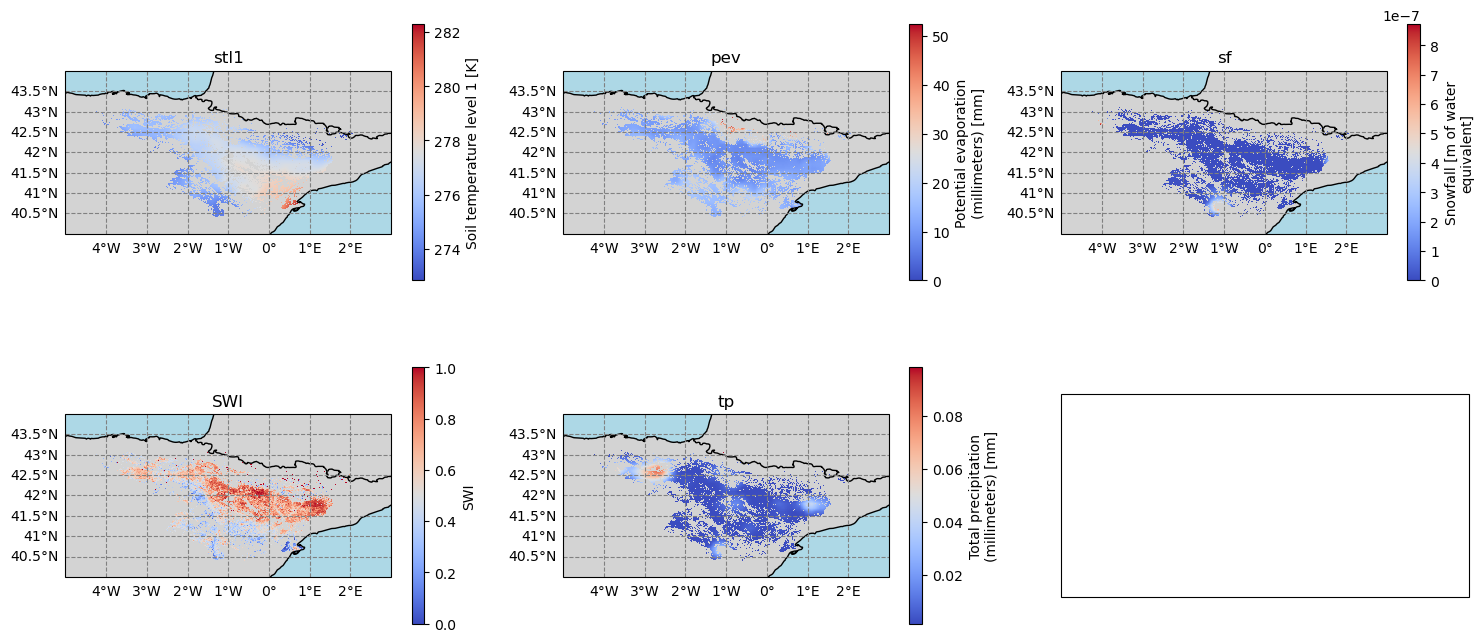

In [229]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

ds = irrigation_input.isel(time=5)
vars_to_plot = ["stl1", "pev", "sf", "SWI", "tp"]

proj = ccrs.PlateCarree()
n_vars = len(vars_to_plot)
n_cols = 3
n_rows = -(-n_vars // n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5*n_cols, 4*n_rows),
    subplot_kw={"projection": proj}
)

for ax, var in zip(axes.flat, vars_to_plot):
    da = ds[var]
    da.plot(ax=ax, transform=proj, cmap="coolwarm", cbar_kwargs={"shrink": 0.6})
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.LAND, facecolor='lightgray')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    ax.set_title(var)
    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray')
    gl.top_labels = False
    gl.right_labels = False

# for ax in axes.flat[n_vars:]:
#     ax.set_visible(False)

plt.tight_layout()
plt.show()


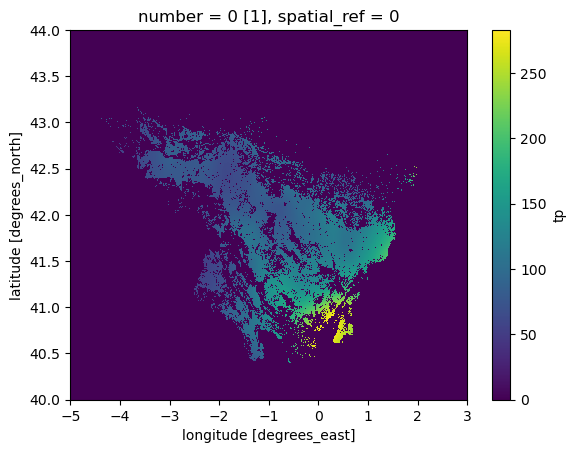

In [230]:
irrigation_input.tp.sum(dim="time", skipna=True).compute().plot()

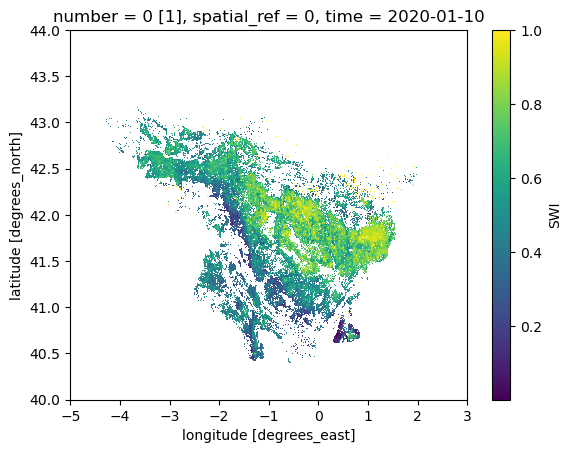

In [231]:
irrigation_input.SWI.isel(time=9).plot()

In [234]:
GridMapping.from_dataset(irrigation_input)

class: **RegularGridMapping**
* is_regular: True
* is_j_axis_up: True
* is_lon_360: False
* crs: GEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],CS[ellipsoidal,2],AXIS["geodetic latitude (Lat)",north,ORDER[1],ANGLEUNIT["degree",0.0174532925199433]],AXIS["geodetic longitude (Lon)",east,ORDER[2],ANGLEUNIT["degree",0.0174532925199433]],USAGE[SCOPE["Horizontal component of 3D system."],AREA["World."],BBOX[-90,-180,90,180]],ID["EPSG",4326]]
* xy_res: (0.008928575, 0.008928575)
* xy_bbox: (-5, 40, 3, 44)
* ij_bbox: (0, 0, 896, 448)
* xy_dim_names: ('lon', 'lat')
* xy_var_names: ('lon', 'lat')
* size: (896, 448)
* tile_size: (128, 128)

In [235]:
0.008928575*111.32

0.9939289689999998